In [9]:
#SCALAR GAUSS BONNET MODIFIED EXAMPLE

# Isotropic Schwarzschild BH example
# see further details in https://github.com/GRChombo/engrenage/wiki/Running-the-black-hole-example

# restart the kernel to clear past work
# (can also do this manually from the Kernel options above)
from IPython.core.display import HTML
HTML("<script>Jupyter.notebook.kernel.restart()</script>")

In [10]:
# load the required python modules
import numpy as np
from scipy.interpolate import interp1d
from scipy.integrate import odeint
from scipy.integrate import solve_ivp
import time
import sys
import random
from tqdm import tqdm
import matplotlib.pyplot as plt
%matplotlib inline

# homemade source code from source folder
sys.path.append('/Users/serdaryildiz/Desktop/GRSerdar/engrenage/source')

from initialdata.bhinitialconditions import *
from backgrounds.sphericalbackground import *
from bssn.constraintsdiagnostic import *
from bssn.ahfinder import *
from core.rhsevolution import *
from core.grid import Grid
from core.spacing import *
from core.display import *
from core.statevector import *
from matter.scalarmatter import *

In [11]:
# Set up the chosen matter class
scalar_mu = 1.0
my_matter = ScalarMatter(scalar_mu)
my_state_vector = StateVector(my_matter)

# Input parameters for grid and evolution here
r_max = 96.0 # outer edge of the grid (including ghosts)
#min_dr = 1 / 16 # roughly 32 points across the BH

min_dr = 1/16
#min_dr = 1 / 128
max_dr = 2

# SinhSpacing
# params = SinhSpacing.get_parameters(r_max, min_dr, max_dr)
# spacing = SinhSpacing(**params)

# CubicSpacing
params = CubicSpacing.get_parameters(r_max, min_dr, max_dr)
spacing = CubicSpacing(**params)

grid = Grid(spacing, my_state_vector)
r = grid.r
num_points = r.size
background = FlatSphericalBackground(r)

# Check grid params
print(params)

{'r_max': 96.0, 'extent': <SpacingExtent.HALF: 0>, 'a': 1.5213625583444466, 'num_points': 140}


In [12]:
initial_state = get_initial_state(grid, background)

#unpackage the vector for readability
(initial_phi, initial_hrr, initial_htt, initial_hpp, 
 initial_K, initial_arr, initial_att, initial_app, 
 initial_lambdar, initial_shiftr, initial_br, initial_lapse, 
 initial_u, initial_v) = np.array_split(initial_state, grid.NUM_VARS)

'''#plot initial conditions
plt.xlabel('r')
plt.plot(r, initial_u, label='u')
#plt.plot(r, initial_v, label='v')
#plt.plot(r, initial_arr, label='arr')
#plt.plot(r, initial_att, label='att')
#plt.plot(r, initial_K, label='K')
#plt.plot(r, initial_phi, label='phi')
#plt.plot(r, initial_hrr, '.', label='hrr') # zero, but plot as dots to see the grid
#plt.plot(r, initial_lapse, label='lapse')
#plt.plot(r, initial_lambdar, label='lambdar')
plt.legend(loc='best')
ax = plt.gcf().gca()
set_grid_on_ax(ax, r)
plt.xlim(-0.2,10.2)
#plt.ylim(-0.001,0.001)'''

"#plot initial conditions\nplt.xlabel('r')\nplt.plot(r, initial_u, label='u')\n#plt.plot(r, initial_v, label='v')\n#plt.plot(r, initial_arr, label='arr')\n#plt.plot(r, initial_att, label='att')\n#plt.plot(r, initial_K, label='K')\n#plt.plot(r, initial_phi, label='phi')\n#plt.plot(r, initial_hrr, '.', label='hrr') # zero, but plot as dots to see the grid\n#plt.plot(r, initial_lapse, label='lapse')\n#plt.plot(r, initial_lambdar, label='lambdar')\nplt.legend(loc='best')\nax = plt.gcf().gca()\nset_grid_on_ax(ax, r)\nplt.xlim(-0.2,10.2)\n#plt.ylim(-0.001,0.001)"

In [13]:
# check the Hamiltonian and momentum constraints are initially satisfied
#Ham, Mom = get_constraints_diagnostic(initial_state, np.array([0]), grid, background, my_matter)

# plot the profile for Ham
#plt.plot(r, Ham[0])
#plt.plot(r, Mom[0])

#plt.xlabel('r')
#plt.ylabel('Ham value')
#ax = plt.gcf().gca()
#set_grid_on_ax(ax, r)
#plt.xlim(-0.5,R+2)
#plt.ylim(-0.1,0.1)

In [14]:
# Check that for a higher resolution the Ham constraint converges (the Mom constraint is trivially zero)

# Input parameters for HR grid
min_dr_HR = 1 / 32 # roughly 64 points across the BH
max_dr_HR = 1

# CubicSpacing
params_HR = CubicSpacing.get_parameters(r_max, min_dr_HR, max_dr_HR)
spacing_HR = CubicSpacing(**params_HR)

grid_HR = Grid(spacing_HR, my_state_vector)
r_HR = grid_HR.r
num_points_HR = r_HR.size
background_HR = FlatSphericalBackground(r_HR)

# Check grid params
print(params_HR)

# Get initial state
initial_state_HR = get_initial_state(grid_HR, background_HR)

'''# check the Hamiltonian and momentum constraints are initially satisfied
Ham_HR, Mom_HR = get_constraints_diagnostic(initial_state_HR, np.array([0]), grid_HR, background_HR, my_matter)

# plot the profiles for Ham
plt.plot(r, Ham[0],'--',label="LR Ham")
plt.plot(r_HR, Ham_HR[0],'-',label="HR Ham")
plt.plot(r_HR, Ham_HR[0] * 2.0**4.0,':',label="LR Ham predicted by 4th order convergence")

plt.xlabel('r')
plt.ylabel('Ham value')
ax = plt.gcf().gca()
set_grid_on_ax(ax, r)
plt.xlim(0.0,2)
plt.ylim(-0.0001,0.0001)
plt.legend();'''

{'r_max': 96.0, 'extent': <SpacingExtent.HALF: 0>, 'a': 1.5213625583444466, 'num_points': 275}


'# check the Hamiltonian and momentum constraints are initially satisfied\nHam_HR, Mom_HR = get_constraints_diagnostic(initial_state_HR, np.array([0]), grid_HR, background_HR, my_matter)\n\n# plot the profiles for Ham\nplt.plot(r, Ham[0],\'--\',label="LR Ham")\nplt.plot(r_HR, Ham_HR[0],\'-\',label="HR Ham")\nplt.plot(r_HR, Ham_HR[0] * 2.0**4.0,\':\',label="LR Ham predicted by 4th order convergence")\n\nplt.xlabel(\'r\')\nplt.ylabel(\'Ham value\')\nax = plt.gcf().gca()\nset_grid_on_ax(ax, r)\nplt.xlim(0.0,2)\nplt.ylim(-0.0001,0.0001)\nplt.legend();'

In [15]:
# find the apparent horizon for a given set of states
omega, ah_radius, bh_mass = get_horizon_diagnostics(initial_state, np.array([0]), grid, background, my_matter)

'''# plot the null expansion omega and its zero crossing
plt.plot(r, omega[0])
plt.axvline(x=ah_radius[0],c="k",label="BH horizon")
plt.xlabel('r')
plt.ylabel('Expansion of null geodesics')
plt.legend(loc="best")
ax = plt.gcf().gca()
set_grid_on_ax(ax, r)
plt.xlim(0,3)
#plt.ylim(-0.1,0.1)'''

print("horizon is at r =", round(ah_radius[0],1))
print("horizon is at r =", ah_radius[0])

horizon is at r = 0.5
horizon is at r = 0.498678538330956


# Start running the simulation

In [64]:
# for control of time integrator and spatial grid
#T = 10 # Maximum evolution time
T = 30
#num_points_t = 128 # time resolution (only for outputs, not for integration, which is decided by python)
num_points_t = 200

# Work out dt and time spacing of outputs
dt = T/num_points_t
t = np.linspace(0, T-dt, num_points_t)

# Solve for the solution using RK45 integration of the ODE
# to make like (older) python odeint method use method='LSODA' instead
# use tqdm package to track progress
with tqdm(total=1000, unit="‰") as progress_bar:
    dense_solution = solve_ivp(get_rhs, [0,T], initial_state, 
                               args=(grid, background, my_matter, progress_bar, [0, T/1000]),
                        #atol=1e-5, rtol=1e-5,
                        max_step = 0.4 * min_dr, #for stability and for KO coeff of 1
                        method='RK45', dense_output=True)

# Interpolate the solution at the time points requested
solution = dense_solution.sol(t).T

  0%|          | 0/1000 [00:00<?, ?‰/s]

# Evolution of scalar field 

In [67]:
inta = 0
for i in range(len(my_state_vector.VARIABLE_NAMES)):
    print('Index: ', inta, 'Variable Name: ',  my_state_vector.VARIABLE_NAMES[i])
    inta = inta +1

Index:  0 Variable Name:  phi
Index:  1 Variable Name:  hrr
Index:  2 Variable Name:  htt
Index:  3 Variable Name:  hpp
Index:  4 Variable Name:  K
Index:  5 Variable Name:  arr
Index:  6 Variable Name:  att
Index:  7 Variable Name:  app
Index:  8 Variable Name:  lambdar
Index:  9 Variable Name:  shiftr
Index:  10 Variable Name:  br
Index:  11 Variable Name:  lapse
Index:  12 Variable Name:  u
Index:  13 Variable Name:  v


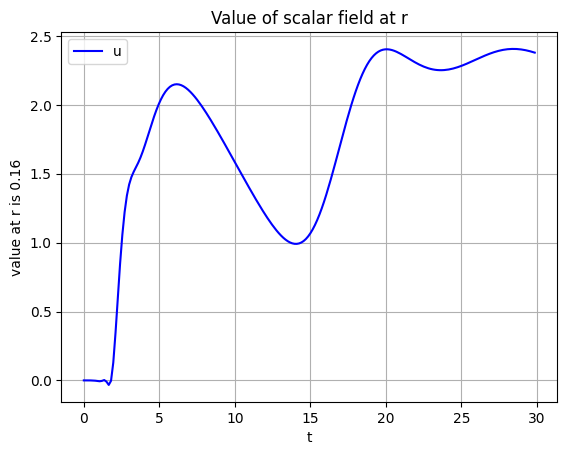

In [68]:
# Plot a single point versus time
idx_u = 12

var1 = idx_u

idx = NUM_GHOSTS + 2 # Choose an inner point
r_i = np.round(r[idx],2)
var1_of_t = solution[:, var1 * num_points + idx]
plt.plot(t, var1_of_t, 'b-', label=my_state_vector.VARIABLE_NAMES[var1])

"""
var2_of_t = solution[:, var2 * num_points + idx]
plt.plot(t, var2_of_t, 'g-', label=my_state_vector.VARIABLE_NAMES[var2])


var3_of_t = solution[:, var3 * num_points + idx]
plt.plot(t, var3_of_t, 'g-', label=my_state_vector.VARIABLE_NAMES[var3])'''
"""
plt.legend(loc='best')
plt.title("Value of scalar field at r")
plt.xlabel('t')
plt.ylabel('value at r is '+str(r_i))
plt.legend(loc='best')
plt.grid()

# Evolution of variables (lapse, shift, K, Conformal factor, ...)

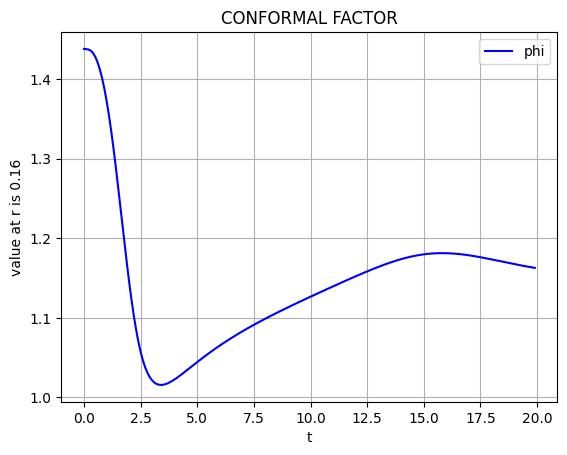

In [52]:
# Plot a single point versus time
idx_u = 11

var1 = 0

idx = NUM_GHOSTS + 2 # Choose an inner point
r_i = np.round(r[idx],2)
var1_of_t = solution[:, var1 * num_points + idx]
plt.plot(t, var1_of_t, 'b-', label=my_state_vector.VARIABLE_NAMES[var1])

"""
var2_of_t = solution[:, var2 * num_points + idx]
plt.plot(t, var2_of_t, 'g-', label=my_state_vector.VARIABLE_NAMES[var2])


var3_of_t = solution[:, var3 * num_points + idx]
plt.plot(t, var3_of_t, 'g-', label=my_state_vector.VARIABLE_NAMES[var3])'''
"""
plt.legend(loc='best')
plt.title('CONFORMAL FACTOR')
plt.xlabel('t')
plt.ylabel('value at r is '+str(r_i))
plt.legend(loc='best')
plt.grid()

## Different variables at different radii and different times

## Conformal factor

Actual AH:  0.498678538330956
Effective AH:  0.47993604100070275
phi at AH:  0.6138508445130746
chi0:  0.08582856709725216
Actual AH:  0.498678538330956
Effective AH:  0.47993604100070275
phi at AH:  0.5671277532338359
chi0:  0.10346612516554118


(0.0, 3.0)

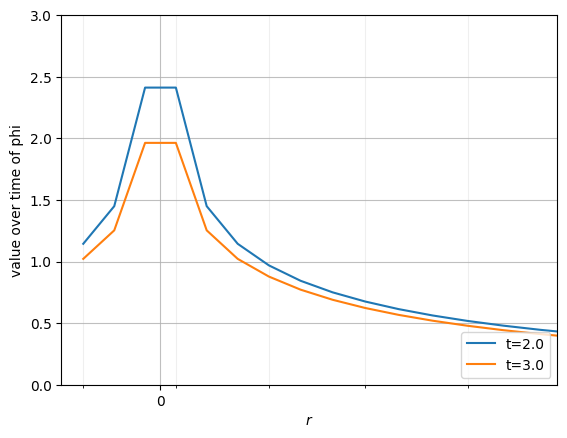

In [53]:
# i is the index of time 
# t_i is the corresponding timie value to that index

# if (i < 1000) and (i % 10 == 0) and (t_i > 9.0):
    # i< 100: times before the 100the time point (only the index of the time)
    # (i % 10 == 0) : every 10th point, avoids to many lines.
    # (t_i > 9.0) : the actual value of the time must be greater than 9 


iii = 10
var = 0
for i, t_i in enumerate(t) :
    if (i < 40) and (i % 10 == 0) and (t_i > 1.0):
        labelt = "t="+str(round(t_i,2))
        f_t = solution[i, var * num_points: (var + 1) * num_points]
        print('Actual AH: ', ah_radius[0])
        print('Effective AH: ', r[iii])
        print('phi at AH: ', f_t[iii])
        print('chi0: ',np.exp(-4*f_t[iii]))
        plt.plot(r, f_t, label=labelt)

plt.legend(loc=4)
plt.xlabel('r')
plt.ylabel('value over time of ' + my_state_vector.VARIABLE_NAMES[var])

ax = plt.gcf().gca()
set_grid_on_ax(ax, r)
plt.xlim(-0.2,0.8)
plt.ylim(0,3)



## Scalar Field

(-1.0, 10.0)

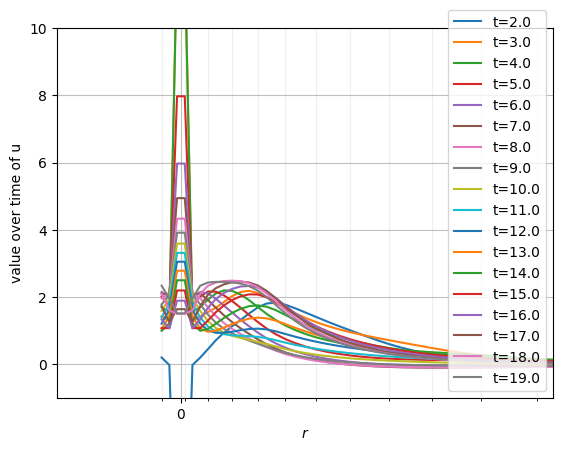

In [54]:
# i is the index of time 
# t_i is the corresponding timie value to that index

# if (i < 1000) and (i % 10 == 0) and (t_i > 9.0):
    # i< 100: times before the 100the time point (only the index of the time)
    # (i % 10 == 0) : every 10th point, avoids to many lines.
    # (t_i > 9.0) : the actual value of the time must be greater than 9 



var = 12
for i, t_i in enumerate(t) :
    if (i < 250) and (i % 10 == 0) and (t_i > 1.0):
        labelt = "t="+str(round(t_i,2))
        f_t = solution[i, var * num_points: (var + 1) * num_points]
        plt.plot(r, f_t, label=labelt)

plt.legend(loc=4)
plt.xlabel('r')
plt.ylabel('value over time of ' + my_state_vector.VARIABLE_NAMES[var])

ax = plt.gcf().gca()
set_grid_on_ax(ax, r)
plt.xlim(-1,3)
plt.ylim(-1,10)


In [55]:
'''# calculate the diagnostics, just the Hamiltonian constraint for now
Ham, Mom = get_constraints_diagnostic(solution, t, grid, background, my_matter)'''

'# calculate the diagnostics, just the Hamiltonian constraint for now\nHam, Mom = get_constraints_diagnostic(solution, t, grid, background, my_matter)'

In [56]:
'''# plot the profile for Ham and Mom at a selection of times

for i, t_i in enumerate(t) :
    if (i < num_points_t) and (i % 30 == 0) :
        labelt = "t="+str(round(t_i,2))
        Ham_t = Ham[i,:]
        ax1 = plt.subplot(211)
        plt.plot(r, Ham_t, label=labelt)
        ax2 = plt.subplot(212)
        Mom_t = np.sqrt(Mom[i,:,i_r]**2 + Mom[i,:,i_t]**2 + Mom[i,:,i_p]**2)
        plt.plot(r, Mom_t, label=labelt)

plt.legend()
ax2.set_xlabel('r')
ax1.set_ylabel('Ham value over time')
ax1.set_xlim(-1,20.0)
ax1.set_ylim(-0.1,0.1)
ax1.grid()
ax2.set_ylabel('Mom_r value over time')
ax2.set_xlim(-1,20.0)
ax2.set_ylim(-0.1,0.1)
ax2.grid()'''

'# plot the profile for Ham and Mom at a selection of times\n\nfor i, t_i in enumerate(t) :\n    if (i < num_points_t) and (i % 30 == 0) :\n        labelt = "t="+str(round(t_i,2))\n        Ham_t = Ham[i,:]\n        ax1 = plt.subplot(211)\n        plt.plot(r, Ham_t, label=labelt)\n        ax2 = plt.subplot(212)\n        Mom_t = np.sqrt(Mom[i,:,i_r]**2 + Mom[i,:,i_t]**2 + Mom[i,:,i_p]**2)\n        plt.plot(r, Mom_t, label=labelt)\n\nplt.legend()\nax2.set_xlabel(\'r\')\nax1.set_ylabel(\'Ham value over time\')\nax1.set_xlim(-1,20.0)\nax1.set_ylim(-0.1,0.1)\nax1.grid()\nax2.set_ylabel(\'Mom_r value over time\')\nax2.set_xlim(-1,20.0)\nax2.set_ylim(-0.1,0.1)\nax2.grid()'

# AH finder

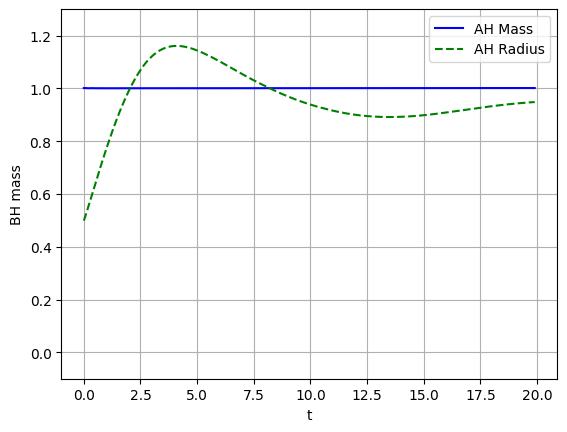

In [57]:
# Track the BH mass, show constant despite gauge evolution
omega, ah_radius, bh_mass = get_horizon_diagnostics(solution, t, grid, background, my_matter)

plt.plot(t, bh_mass, 'b-', label="AH Mass")
plt.plot(t, ah_radius, 'g--', label="AH Radius")
plt.legend(loc='best')
plt.xlabel('t')
plt.ylabel('BH mass')
plt.legend(loc='best')
plt.ylim(-0.1,1.3)

#print('t: ', t)
#print('R_{AH}: ', ah_radius)
#print(len(ah_radius))


plt.grid()

# Scalar field evolution at AH

In [58]:
interpolated_u_of_r_at_different_times = []

for timepoint in range(len(t)):
    interpolated_u_of_r_at_different_times.append(interp1d(r,solution[timepoint, var * num_points: (var + 1) * num_points],  kind='cubic', fill_value='extrapolate'))
    
# This is a list of all of the interpolation functions (function of value of u in terms value of r [gotten in an interpolated way]) at all the different time steps
#print(interpolated_u_of_r_at_different_times)


In [59]:
u_of_ahR = []

for idx_ahr, ahr in enumerate(ah_radius):
    u_of_ahR.append(interpolated_u_of_r_at_different_times[idx_ahr](ahr))
    
#print(u_of_ahR)

final value of scalar field:  1.173912680633423


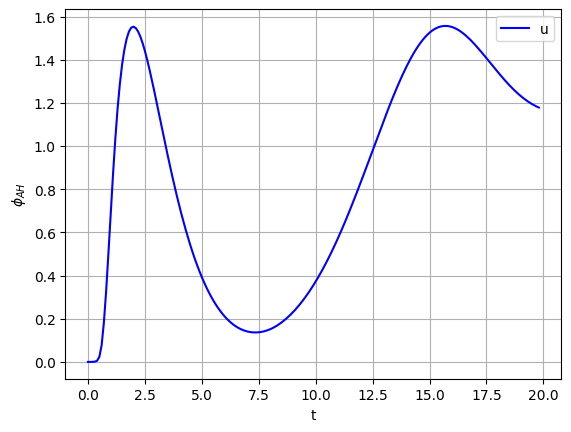

In [60]:
maxidx = 199

plt.plot(t[:maxidx], u_of_ahR[:maxidx], 'b-', label='u')
plt.legend(loc='best')
plt.xlabel('t')
plt.ylabel('$\phi_{AH}$')
plt.legend(loc='best')
plt.grid()

print('final value of scalar field: ', u_of_ahR[maxidx])

# Conformal factor at apparant horizon

In [61]:
var0 = 0

interpolated_phi_of_r_at_different_times = []

for timepoint in range(len(t)):
    interpolated_phi_of_r_at_different_times.append(interp1d(r,solution[timepoint, var0 * num_points: (var0 + 1) * num_points],  kind='cubic', fill_value='extrapolate'))
    
# This is a list of all of the interpolation functions (function of value of u in terms value of r [gotten in an interpolated way]) at all the different time steps

In [62]:
phi_of_ahR = []

for idx_ahr, ahr in enumerate(ah_radius):
    phi_of_ahR.append(interpolated_phi_of_r_at_different_times[idx_ahr](ahr))
    
#print(u_of_ahR)

initial value of chi:  0.06217484950537183


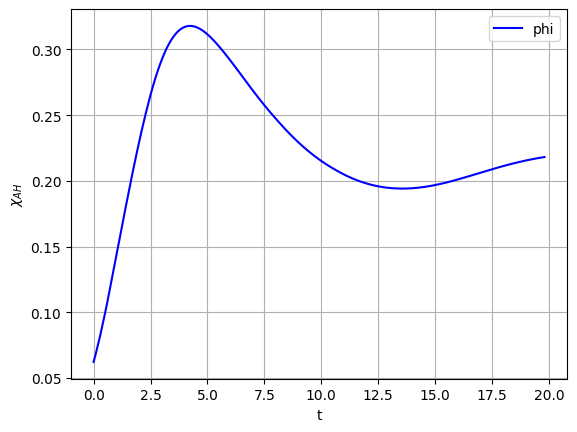

In [63]:
maxidx = 199

def chicalc(phi):
    return np.exp(-4*phi)

listofchi = []
for i in range(len(phi_of_ahR)):
    listofchi.append(chicalc(phi_of_ahR[i]))

plt.plot(t[:maxidx], listofchi[:maxidx], 'b-', label='phi')
plt.legend(loc='best')
plt.xlabel('t')
plt.ylabel('$\chi_{AH}$')
plt.legend(loc='best')
plt.grid()

print('initial value of chi: ', listofchi[0])

# L_GB term over t

# Coupling function analysis

(0.0, 0.6)

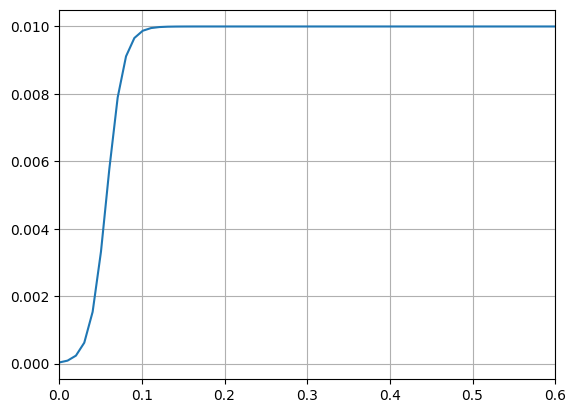

In [32]:
chi = np.linspace(0, 1, 100)

def function_of_lambda(chi0, lambda_GB):
    return (lambda_GB)/(1+np.exp(-100*(chi-chi0)))

plt.plot(chi, function_of_lambda(0.0575, 0.01))
plt.grid()
plt.xlim(0,0.6)

# Kretschmann scalar VS LGB term

The coordinate transformation to go from Schwarzschild ($r$) to isotropic ($R$) coordinates

$r = R \left( 1+\frac{(M)^2}{4R}\right)$

In Schwarzschil coordinates the K scalar is given by

$K = \frac{48}{r^6}$

Hence what we need

$K = \frac{48}{\left(R \left( 1+\frac{(M)^2}{4R}\right)\right)^6}$

The K scalar is equal to the GB term at first order (if we neglect backreaction)

 

In [33]:
GB_vals_ =data = [
    1.27917218e-27, 2.68700163e-25, 8.32528897e-24, 2.09998259e+08,
    4.96708054e+04, 1.66217090e+05, 3.16314262e+04, 9.24216703e+03,
    3.48736765e+03, 1.56951835e+03, 8.02665485e+02, 4.51377888e+02,
    2.72689878e+02, 1.74021139e+02, 1.15873732e+02, 7.97747433e+01,
    5.64023377e+01, 4.07436793e+01, 2.99545533e+01, 2.23460053e+01,
    1.68753607e+01, 1.28771230e+01, 9.91417631e+00, 7.69220486e+00,
    6.00873241e+00, 4.72182861e+00, 3.73035993e+00, 2.96121872e+00,
    2.36088281e+00, 1.88972731e+00, 1.51812324e+00, 1.22371919e+00,
    9.89520086e-01, 8.02511728e-01, 6.52664636e-01, 5.32204866e-01,
    4.35075196e-01, 3.56533494e-01, 2.92850983e-01, 2.41083923e-01,
    1.98899716e-01, 1.64443668e-01, 1.36236347e-01, 1.13094111e-01,
    9.40672905e-02, 7.83919049e-02, 6.54517963e-02, 5.47488261e-02,
    4.58793388e-02, 3.85155148e-02, 3.23905538e-02, 2.72868678e-02,
    2.30266483e-02, 1.94643110e-02, 1.64804297e-02, 1.39768552e-02,
    1.18727783e-02, 1.01015488e-02, 8.60809873e-03, 7.34685227e-03,
    6.28002596e-03, 5.37624480e-03, 4.60941290e-03, 3.95779037e-03,
    3.40323761e-03, 2.93059540e-03, 2.52717573e-03, 2.18234277e-03,
    1.88716755e-03, 1.63414292e-03, 1.41694786e-03, 1.23025237e-03,
    1.06955563e-03, 9.31051644e-04, 8.11517435e-04, 7.08219979e-04,
    6.18838534e-04, 5.41399779e-04, 4.74223559e-04, 4.15877436e-04,
    3.65138567e-04, 3.20961682e-04, 2.82452160e-04, 2.48843344e-04,
    2.19477417e-04, 1.93789253e-04, 1.71292763e-04, 1.51569333e-04,
    1.34258033e-04, 1.19047295e-04, 1.05667852e-04, 9.38867280e-05,
    8.35021120e-05, 7.43389971e-05, 6.62454496e-05, 5.90894222e-05,
    5.27560268e-05, 4.71451971e-05, 4.21696843e-05, 3.77533351e-05,
    3.38296126e-05, 3.03403220e-05, 2.72345132e-05, 2.44675349e-05,
    2.20002167e-05, 1.97981631e-05, 1.78311425e-05, 1.60725576e-05,
    1.44989866e-05, 1.30897849e-05, 1.18267391e-05, 1.06937663e-05,
    9.67665172e-06, 8.76282113e-06, 7.94114142e-06, 7.20174705e-06,
    6.53588826e-06, 5.93579832e-06, 5.39457733e-06, 4.90609046e-06,
    4.46487865e-06, 4.06608028e-06, 3.70536234e-06, 3.37885993e-06,
    3.08312299e-06, 2.81506946e-06, 2.57194387e-06, 2.35128097e-06,
    2.15087345e-06, 1.96874356e-06, 1.80311793e-06, 1.65240533e-06,
    1.51517694e-06, 1.39014886e-06, 1.27616667e-06, 1.17219161e-06,
    1.07728838e-06, 0.0, 0.0, 0.0
]



In [34]:
# To obtain the scalar K in iso SZ coordinates

def iso_to_sz(R):
    return R*(1+ 1/(2*R))**2

def Kretschmann(r):
    return 48/(r**6)



# Checking the LGB term with Kretschman scalar

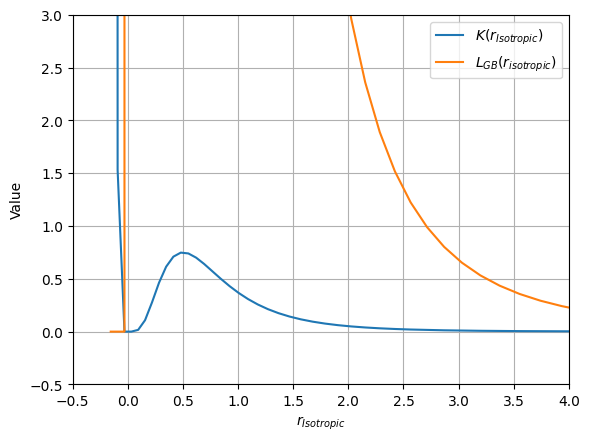

In [23]:


#plt.plot(sz_r, Kretschmann(sz_r), label='K')
#plt.plot(sz_r, GB_vals, label = 'GB_Term')

plt.plot(r, Kretschmann(iso_to_sz(r)), label='$K(r_{Isotropic})$')
plt.plot(r, GB_vals_, label = '$L_{GB} (r_{isotropic})$')


plt.legend(loc='best')
plt.xlabel('$r_{Isotropic}$')
plt.ylabel('Value')
plt.legend(loc='best')
plt.xlim(-0.5,4)
plt.ylim(-0.5,3)
plt.grid()

# Check different lines of L_GB with Kretschman scalar

In [12]:
'''line1 = [0.0, 0.0, 0.0, 1.61320354e-31, 1.33303668e-30, 1.50433946e-31, -4.43441555e-32, -3.00481784e-32, 7.50444663e-33, -0.0, -3.53065783e-33, -0.0, -0.0, 3.30404129e-34, 3.42191057e-34, 1.85365537e-34, -0.0, 6.04179686e-35, -0.0, -0.0, -0.0, 1.70831946e-35, 2.72837182e-36, -0.0, -0.0, 1.51669725e-36, -0.0, -0.0, -0.0, -7.44484694e-38, 9.90165218e-38, -1.30748049e-37, -0.0, -0.0, -3.35892399e-38, 1.95604745e-38, -5.09436414e-39, -1.00230326e-39, -0.0, 0.0, -1.97593847e-39, 0.0, 2.53410377e-39, 0.0, 6.17184510e-40, 0.0, 0.0, -9.90481354e-40, 0.0, -1.61625565e-39, -7.22868711e-40, 0.0, -5.70739000e-40, 0.0, -4.45121195e-40, 1.95921340e-40, 1.72201342e-40, 0.0, 0.0, 0.0, -2.03496879e-40, 0.0, 0.0, -6.82481925e-41, 0.0, -2.61420506e-41, -9.15416818e-41, 0.0, -7.02178094e-41, 0.0, -6.74255405e-42, 0.0, 0.0, 0.0, -8.00346458e-42, 0.0, -3.09376787e-42, 0.0, 0.0, 0.0, -1.86312332e-42, 0.0, 0.0, -2.56612233e-42, -2.26953480e-42, 0.0, 0.0, 7.88364976e-43, -6.99114327e-43, -6.20560198e-43, -1.10262014e-42, 4.89923485e-43, 0.0, 7.76095217e-43, 6.91612552e-43, 0.0, -2.75098699e-43, 2.45540122e-43, 1.09718461e-43, 2.45269284e-44, 1.75592390e-43, -7.86203010e-44, 0.0, 1.26385295e-43, 0.0, 1.01850326e-43, 9.15004480e-44, 0.0, 0.0, 6.67025583e-44, -6.01264855e-44, 0.0, 4.89102311e-44, 0.0, 9.97603905e-45, -4.50779756e-45, 1.63416781e-44, -1.47511787e-44, -1.33902561e-44, -6.06644236e-45, 5.49943089e-45, -2.49617440e-45, -9.07810954e-45, -4.11426808e-45, -3.74865175e-45, -3.40630364e-45, 6.20318770e-45, -5.65218095e-45, 1.28722395e-45, -4.70632558e-45, 4.26849861e-45, 1.96259910e-45, -1.78463242e-45, 0.0, -7.48080731e-46, -1.36802338e-45, 6.23125255e-46, -0.0, -0.0, -0.0]

line2 = [1.27917218e-27, 2.68700163e-25, 8.32528897e-24, 2.09969076e+08, 2.50530703e+03, 1.60102628e+05, 2.87772472e+04, 7.77771601e+03, 2.65675397e+03, 1.06330429e+03, 4.77466917e+02, 2.33948007e+02, 1.22707062e+02, 6.79512647e+01, 3.93215683e+01, 2.35911281e+01, 1.45842571e+01, 9.24543025e+00, 5.98669061e+00, 3.94726489e+00, 2.64326572e+00, 1.79392965e+00, 1.23178381e+00, 8.54478578e-01, 5.98112837e-01, 4.22030182e-01, 2.99927249e-01, 2.14532038e-01, 1.54352042e-01, 1.11649571e-01, 8.11596935e-02, 5.92658953e-02, 4.34626911e-02, 3.20008757e-02, 2.36506779e-02, 1.75419945e-02, 1.30556085e-02, 9.74848711e-03, 7.30208630e-03, 5.48632027e-03, 4.13428713e-03, 3.12443338e-03, 2.36789890e-03, 1.79949205e-03, 1.37122331e-03, 1.04765178e-03, 8.02522685e-04, 6.16328183e-04, 4.74531696e-04, 3.66270706e-04, 2.83406040e-04, 2.19822891e-04, 1.70915389e-04, 1.33205415e-04, 1.04059911e-04, 8.14806677e-05, 6.39475908e-05, 5.03015513e-05, 3.96565918e-05, 3.13339788e-05, 2.48125420e-05, 1.96911910e-05, 1.56605575e-05, 1.24814913e-05, 9.96871806e-06, 7.97839029e-06, 6.39858504e-06, 5.14203359e-06, 4.14054752e-06, 3.34073608e-06, 2.70070869e-06, 2.18753081e-06, 1.77525683e-06, 1.44340610e-06, 1.17577985e-06, 9.59540856e-07, 7.84496144e-07, 6.42536801e-07, 5.27199613e-07, 4.33323402e-07, 3.56779069e-07, 2.94257143e-07, 2.43100259e-07, 2.01170837e-07, 1.66746350e-07, 1.38436298e-07, 1.15116256e-07, 9.58753998e-08, 7.99746753e-08, 6.68133992e-08, 5.59025421e-08, 4.68433221e-08, 3.93100231e-08, 3.30361814e-08, 2.78034622e-08, 2.34326865e-08, 1.97765821e-08, 1.67139169e-08, 1.41447443e-08, 1.19865428e-08, 1.01710782e-08, 8.64184774e-09, 7.35199568e-09, 6.26261138e-09, 5.34133660e-09, 4.56122490e-09, 3.89980577e-09, 3.33831587e-09, 2.86106646e-09, 2.45492232e-09, 2.10887179e-09, 1.81367155e-09, 1.56155281e-09, 1.34597785e-09, 1.16143816e-09, 1.00328665e-09, 8.67598264e-10, 7.51053786e-10, 6.50843017e-10, 5.64583940e-10, 4.90255143e-10, 4.26139275e-10, 3.70775665e-10, 3.22920574e-10, 2.81513810e-10, 2.45650663e-10, 2.14558269e-10, 1.87575699e-10, 1.64137150e-10, 1.43757754e-10, 1.26021576e-10, 1.10571450e-10, 9.71003708e-11, 8.53441870e-11, 7.50753969e-11, 6.60978750e-11, 5.82423825e-11, 0.0, 0.0, 0.0]

line3 = [0.0] * 144  # since all are zeros

line4 = [-0.0, -0.0, -0.0, 2.91834390e+04, 4.71654984e+04, 6.11446205e+03, 2.85417899e+03, 1.46445101e+03, 8.30613672e+02, 5.06214061e+02, 3.25198568e+02, 2.17429881e+02, 1.49982816e+02, 1.06069874e+02, 7.65521635e+01, 5.61836152e+01, 4.18180806e+01, 3.14982490e+01, 2.39678627e+01, 1.83987404e+01, 1.42320950e+01, 1.10831933e+01, 8.68239250e+00, 6.83772628e+00, 5.41061957e+00, 4.29979842e+00, 3.43043268e+00, 2.74668668e+00, 2.20653077e+00, 1.77807774e+00, 1.43696355e+00, 1.16445330e+00, 9.46057395e-01, 7.70510852e-01, 6.29013958e-01, 5.14662872e-01, 4.22019587e-01, 3.46785007e-01, 2.85548897e-01, 2.35597603e-01, 1.94765429e-01, 1.61319234e-01, 1.33868448e-01, 1.11294619e-01, 9.26960672e-02, 7.73442532e-02, 6.46492736e-02, 5.41324979e-02, 4.54048071e-02, 3.81492441e-02, 3.21071478e-02, 2.70670449e-02, 2.28557329e-02, 1.93311056e-02, 1.63763698e-02, 1.38953745e-02, 1.18088307e-02, 1.00512472e-02, 8.56844214e-03, 7.31551829e-03, 6.25521342e-03, 5.35655361e-03, 4.59375234e-03, 3.94530888e-03, 3.39326889e-03, 2.92261701e-03, 2.52077715e-03, 2.17720074e-03, 1.88302701e-03, 1.63080219e-03, 1.41424716e-03, 1.22806484e-03, 1.06778038e-03, 9.29608238e-04, 8.10341656e-04, 7.07260439e-04, 6.18054038e-04, 5.40757242e-04, 4.73696360e-04, 4.15444113e-04, 3.64781788e-04, 3.20667425e-04, 2.82209060e-04, 2.48642173e-04, 2.19310671e-04, 1.93650817e-04, 1.71177646e-04, 1.51473458e-04, 1.34178058e-04, 1.18980481e-04, 1.05611950e-04, 9.38398846e-05, 8.34628020e-05, 7.43059609e-05, 6.62176461e-05, 5.90659895e-05, 5.27362502e-05, 4.71284832e-05, 4.21555395e-05, 3.77413486e-05, 3.38194415e-05, 3.03316801e-05, 2.72271612e-05, 2.44612723e-05, 2.19948753e-05, 1.97936019e-05, 1.78272427e-05, 1.60692193e-05, 1.44961255e-05, 1.30873300e-05, 1.18246303e-05, 1.06919526e-05, 9.67509017e-06, 8.76147515e-06, 7.93997998e-06, 7.20074376e-06, 6.53502066e-06, 5.93504727e-06, 5.39392649e-06, 4.90552588e-06, 4.46438840e-06, 4.06565414e-06, 3.70499156e-06, 3.37853701e-06, 3.08284148e-06, 2.81482381e-06, 2.57172932e-06, 2.35109339e-06, 2.15070931e-06, 1.96859980e-06, 1.80299191e-06, 1.65229476e-06, 1.51507984e-06, 1.39006352e-06, 1.27609160e-06, 1.17212551e-06, 1.07723014e-06, -0.0, -0.0, -0.0]
'''

'line1 = [0.0, 0.0, 0.0, 1.61320354e-31, 1.33303668e-30, 1.50433946e-31, -4.43441555e-32, -3.00481784e-32, 7.50444663e-33, -0.0, -3.53065783e-33, -0.0, -0.0, 3.30404129e-34, 3.42191057e-34, 1.85365537e-34, -0.0, 6.04179686e-35, -0.0, -0.0, -0.0, 1.70831946e-35, 2.72837182e-36, -0.0, -0.0, 1.51669725e-36, -0.0, -0.0, -0.0, -7.44484694e-38, 9.90165218e-38, -1.30748049e-37, -0.0, -0.0, -3.35892399e-38, 1.95604745e-38, -5.09436414e-39, -1.00230326e-39, -0.0, 0.0, -1.97593847e-39, 0.0, 2.53410377e-39, 0.0, 6.17184510e-40, 0.0, 0.0, -9.90481354e-40, 0.0, -1.61625565e-39, -7.22868711e-40, 0.0, -5.70739000e-40, 0.0, -4.45121195e-40, 1.95921340e-40, 1.72201342e-40, 0.0, 0.0, 0.0, -2.03496879e-40, 0.0, 0.0, -6.82481925e-41, 0.0, -2.61420506e-41, -9.15416818e-41, 0.0, -7.02178094e-41, 0.0, -6.74255405e-42, 0.0, 0.0, 0.0, -8.00346458e-42, 0.0, -3.09376787e-42, 0.0, 0.0, 0.0, -1.86312332e-42, 0.0, 0.0, -2.56612233e-42, -2.26953480e-42, 0.0, 0.0, 7.88364976e-43, -6.99114327e-43, -6.20560198e-43, -1.

In [13]:
line1 = [
    0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 1.61320354e-31,
    1.33303668e-30, 1.50433946e-31, -4.43441555e-32, -3.00481784e-32,
    7.50444663e-33, -0.00000000e+00, -3.53065783e-33, -0.00000000e+00,
    -0.00000000e+00, 3.30404129e-34, 3.42191057e-34, 1.85365537e-34,
    -0.00000000e+00, 6.04179686e-35, -0.00000000e+00, -0.00000000e+00,
    -0.00000000e+00, 1.70831946e-35, 2.72837182e-36, -0.00000000e+00,
    -0.00000000e+00, 1.51669725e-36, -0.00000000e+00, -0.00000000e+00,
    -0.00000000e+00, -7.44484694e-38, 9.90165218e-38, -1.30748049e-37,
    -0.00000000e+00, -0.00000000e+00, -3.35892399e-38, 1.95604745e-38,
    -5.09436414e-39, -1.00230326e-39, -0.00000000e+00, 0.00000000e+00,
    -1.97593847e-39, 0.00000000e+00, 2.53410377e-39, 0.00000000e+00,
    6.17184510e-40, 0.00000000e+00, 0.00000000e+00, -9.90481354e-40,
    0.00000000e+00, -1.61625565e-39, -7.22868711e-40, 0.00000000e+00,
    -5.70739000e-40, 0.00000000e+00, -4.45121195e-40, 1.95921340e-40,
    1.72201342e-40, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00,
    -2.03496879e-40, 0.00000000e+00, 0.00000000e+00, -6.82481925e-41,
    0.00000000e+00, -2.61420506e-41, -9.15416818e-41, 0.00000000e+00,
    -7.02178094e-41, 0.00000000e+00, -6.74255405e-42, 0.00000000e+00,
    0.00000000e+00, 0.00000000e+00, -8.00346458e-42, 0.00000000e+00,
    -3.09376787e-42, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00,
    -1.86312332e-42, 0.00000000e+00, 0.00000000e+00, -2.56612233e-42,
    -2.26953480e-42, 0.00000000e+00, 0.00000000e+00, 7.88364976e-43,
    -6.99114327e-43, -6.20560198e-43, -1.10262014e-42, 4.89923485e-43,
    0.00000000e+00, 7.76095217e-43, 6.91612552e-43, 0.00000000e+00,
    -2.75098699e-43, 2.45540122e-43, 1.09718461e-43, 2.45269284e-44,
    1.75592390e-43, -7.86203010e-44, 0.00000000e+00, 1.26385295e-43,
    0.00000000e+00, 1.01850326e-43, 9.15004480e-44, 0.00000000e+00,
    0.00000000e+00, 6.67025583e-44, -6.01264855e-44, 0.00000000e+00,
    4.89102311e-44, 0.00000000e+00, 9.97603905e-45, -4.50779756e-45,
    1.63416781e-44, -1.47511787e-44, -1.33902561e-44, -6.06644236e-45,
    5.49943089e-45, -2.49617440e-45, -9.07810954e-45, -4.11426808e-45,
    -3.74865175e-45, -3.40630364e-45, 6.20318770e-45, -5.65218095e-45,
    1.28722395e-45, -4.70632558e-45, 4.26849861e-45, 1.96259910e-45,
    -1.78463242e-45, 0.00000000e+00, -7.48080731e-46, -1.36802338e-45,
    6.23125255e-46, -0.00000000e+00, -0.00000000e+00, -0.00000000e+00
]

line2 = [
    0.00000000e+00, 0.00000000e+00, 0.00000000e+00, -3.56029169e-11,
    -1.69425635e-13, -2.22113829e-13, 1.70583905e-12, 4.35124847e-12,
    1.51809561e-12, 2.25663022e-12, 1.73188531e-12, 1.19228885e-12,
    2.65809027e-13, 3.26489126e-13, 3.73205252e-13, 3.55133739e-13,
    7.08175718e-14, 1.79697217e-13, 1.06134668e-13, 3.25412317e-14,
    5.70089408e-14, 8.85252631e-14, 1.90973909e-14, 8.94504920e-15,
    6.99928112e-15, 1.63727299e-14, 1.28373281e-14, 1.00854866e-14,
    1.32062942e-14, 2.80240247e-15, 4.40281547e-15, 6.51557904e-15,
    1.73762856e-15, 2.20036181e-15, 3.27386693e-15, 3.13355075e-15,
    1.39721245e-15, 6.75549179e-16, 1.52445324e-15, 1.01153249e-15,
    4.10410825e-16, 4.25371975e-16, 3.82444107e-16, 3.41161590e-16,
    7.73312470e-17, 2.87266419e-16, 1.01421069e-16, 1.37468190e-16,
    4.57202521e-17, 1.20115849e-16, 9.88764946e-17, 1.00234832e-16,
    6.22507928e-17, 3.45009893e-17, 2.86225323e-17, 1.79145717e-17,
    2.22585017e-17, 6.32265701e-18, 1.04031807e-17, 2.58554242e-17,
    1.68953158e-17, 1.72196331e-17, 1.77779824e-18, 5.78923111e-18,
    3.07823075e-18, 2.60458592e-18, 6.97289063e-18, 4.44859290e-18,
    5.34665299e-18, 3.48824029e-18, 7.03113744e-19, 3.10665986e-18,
    2.65842426e-18, 1.42393996e-18, 1.11119833e-18, 6.39930045e-19,
    4.60377912e-19, 8.64524938e-19, 6.78967537e-19, 1.79715409e-19,
    2.56241412e-19, 6.58521502e-19, 6.09411542e-19, 2.99159700e-19,
    5.18128229e-19, 1.51911623e-19, 2.19608332e-19, 1.91806433e-19,
    1.51095425e-19, 1.32284142e-19, 1.79775674e-19, 1.12955133e-19,
    7.95522692e-20, 1.39228142e-19, 1.14972198e-19, 4.75854792e-20,
    4.79205079e-20, 8.42437640e-20, 2.81661168e-20, 8.52591034e-21,
    5.11677758e-20, 2.60421842e-20, 3.74346517e-20, 3.83580666e-20,
    6.96249108e-21, 3.64309754e-20, 3.06734981e-20, 1.61453971e-20,
    1.15539079e-20, 2.05564719e-20, 1.83873142e-20, 4.17113669e-21,
    1.47496870e-20, 1.07581460e-20, 3.74607625e-21, 2.03762237e-21,
    6.60395503e-21, 4.86807331e-21, 4.38318790e-21, 3.51415114e-21,
    2.77623060e-21, 1.08753424e-21, 3.22319002e-21, 2.33441313e-21,
    1.58790309e-21, 1.43719964e-21, 3.44769100e-21, 2.34693923e-21,
    5.40790285e-22, 2.25241574e-21, 2.48214487e-21, 1.33049145e-21,
    1.08976807e-21, 4.44596420e-22, 6.04125923e-22, 1.18606113e-21,
    3.36287434e-22, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00
]

line3 = [0.0] * 144

line4 = [
    -0.00000000e+00, -0.00000000e+00, -0.00000000e+00, 2.91834390e+04,
    4.71654984e+04, 6.11446205e+03, 2.85417899e+03, 1.46445101e+03,
    8.30613672e+02, 5.06214061e+02, 3.25198568e+02, 2.17429881e+02,
    1.49982816e+02, 1.06069874e+02, 7.65521635e+01, 5.61836152e+01,
    4.18180806e+01, 3.14982490e+01, 2.39678627e+01, 1.83987404e+01,
    1.42320950e+01, 1.10831933e+01, 8.68239250e+00, 6.83772628e+00,
    5.41061957e+00, 4.29979842e+00, 3.43043268e+00, 2.74668668e+00,
    2.20653077e+00, 1.77807774e+00, 1.43696355e+00, 1.16445330e+00,
    9.46057395e-01, 7.70510852e-01, 6.29013958e-01, 5.14662872e-01,
    4.22019587e-01, 3.46785007e-01, 2.85548897e-01, 2.35597603e-01,
    1.94765429e-01, 1.61319234e-01, 1.33868448e-01, 1.11294619e-01,
    9.26960672e-02, 7.73442532e-02, 6.46492736e-02, 5.41324979e-02,
    4.54048071e-02, 3.81492441e-02, 3.21071478e-02, 2.70670449e-02,
    2.28557329e-02, 1.93311056e-02, 1.63763698e-02, 1.38953745e-02,
    1.18088307e-02, 1.00512472e-02, 8.56844214e-03, 7.31551829e-03,
    6.25521342e-03, 5.35655361e-03, 4.59375234e-03, 3.94530888e-03,
    3.39326889e-03, 2.92261701e-03, 2.52077715e-03, 2.17720074e-03,
    1.88302701e-03, 1.63080219e-03, 1.41424716e-03, 1.22806484e-03,
    1.06778038e-03, 9.29608238e-04, 8.10341656e-04, 7.07260439e-04,
    6.18054038e-04, 5.40757242e-04, 4.73696360e-04, 4.15444113e-04,
    3.64781788e-04, 3.20667425e-04, 2.82209060e-04, 2.48642173e-04,
    2.19310671e-04, 1.93650817e-04, 1.71177646e-04, 1.51473458e-04,
    1.34178058e-04, 1.18980481e-04, 1.05611950e-04, 9.38398846e-05,
    8.34628020e-05, 7.43059609e-05, 6.62176461e-05, 5.90659895e-05,
    5.27362502e-05, 4.71284832e-05, 4.21555395e-05, 3.77413486e-05,
    3.38194415e-05, 3.03316801e-05, 2.72271612e-05, 2.44612723e-05,
    2.19948753e-05, 1.97936019e-05, 1.78272427e-05, 1.60692193e-05,
    1.44961255e-05, 1.30873300e-05, 1.18246303e-05, 1.06919526e-05,
    9.67509017e-06, 8.76147515e-06, 7.93997998e-06, 7.20074376e-06,
    6.53502066e-06, 5.93504727e-06, 5.39392649e-06, 4.90552588e-06,
    4.46438840e-06, 4.06565414e-06, 3.70499156e-06, 3.37853701e-06,
    3.08284148e-06, 2.81482381e-06, 2.57172932e-06, 2.35109339e-06,
    2.15070931e-06, 1.96859980e-06, 1.80299191e-06, 1.65229476e-06,
    1.51507984e-06, 1.39006352e-06, 1.27609160e-06, 1.17212551e-06,
    1.07723014e-06, -0.00000000e+00, -0.00000000e+00, -0.00000000e+00
]


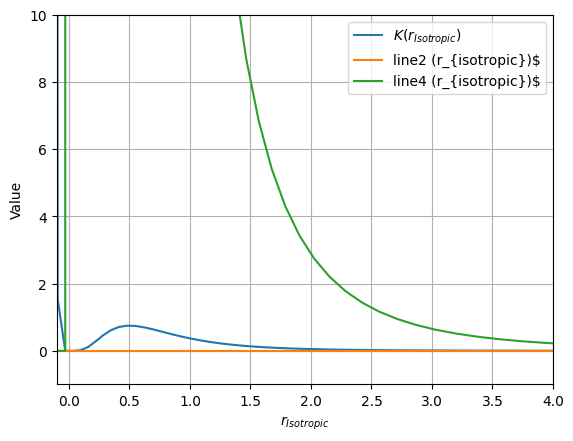

In [14]:


#plt.plot(sz_r, Kretschmann(sz_r), label='K')
#plt.plot(r, GB_vals_, label = 'GB_Term')

plt.plot(r, Kretschmann(iso_to_sz(r)), label='$K(r_{Isotropic})$')
#plt.plot(r, line1, label = 'line1 (r_{isotropic})$')
plt.plot(r, line2, label = 'line2 (r_{isotropic})$')
#plt.plot(r, line3, label = 'line3 (r_{isotropic})$')
plt.plot(r, line4, label = 'line4 (r_{isotropic})$')






plt.legend(loc='best')
plt.xlabel('$r_{Isotropic}$')
plt.ylabel('Value')
plt.legend(loc='best')
'''plt.xlim(-0.1,2)
plt.ylim(-10,1200)'''

plt.xlim(-0.1,4)
plt.ylim(-1,10)
plt.grid()

# Comparing the Kretschman scalar with gaussbonnet term multiplied with S function

In [16]:
GB_vals_new = [
    2.68840436e-35, 4.36800761e-33, 1.27484804e-31, 3.21569461e+00,
    8.07451897e-04, 3.49334325e-03, 1.14001858e-03, 7.71501173e-04,
    8.92713521e-04, 1.57381917e-03, 3.87096028e-03, 1.23758609e-02,
    4.84889207e-02, 2.18836784e-01, 9.74698650e-01, 2.50311914e+00,
    2.64002781e+00, 2.02178555e+00, 1.49647621e+00, 1.11719832e+00,
    8.43759611e-01, 6.43855439e-01, 4.95708754e-01, 3.84610238e-01,
    3.00436620e-01, 2.36091430e-01, 1.86517997e-01, 1.48060936e-01,
    1.18044140e-01, 9.44863654e-02, 7.59061620e-02, 6.11859597e-02,
    4.94760043e-02, 4.01255864e-02, 3.26332318e-02, 2.66102433e-02,
    2.17537598e-02, 1.78266747e-02, 1.46425491e-02, 1.20541961e-02,
    9.94498578e-03, 8.22218339e-03, 6.81181736e-03, 5.65470556e-03,
    4.70336453e-03, 3.91959525e-03, 3.27258982e-03, 2.73744131e-03,
    2.29396694e-03, 1.92577574e-03, 1.61952769e-03, 1.36434339e-03,
    1.15133242e-03, 9.73215549e-04, 8.24021485e-04, 6.98842758e-04,
    5.93638913e-04, 5.05077438e-04, 4.30404937e-04, 3.67342613e-04,
    3.14001298e-04, 2.68812240e-04, 2.30470645e-04, 1.97889519e-04,
    1.70161881e-04, 1.46529770e-04, 1.26358787e-04, 1.09117139e-04,
    9.43583777e-05, 8.17071462e-05, 7.08473932e-05, 6.15126186e-05,
    5.34777817e-05, 4.65525822e-05, 4.05758718e-05, 3.54109990e-05,
    3.09419267e-05, 2.70699889e-05, 2.37111780e-05, 2.07938718e-05,
    1.82569283e-05, 1.60480841e-05, 1.41226080e-05, 1.24421672e-05,
    1.09738709e-05, 9.68946267e-06, 8.56463814e-06, 7.57846665e-06,
    6.71290163e-06, 5.95236473e-06, 5.28339262e-06, 4.69433640e-06,
    4.17510560e-06, 3.71694986e-06, 3.31227248e-06, 2.95447111e-06,
    2.63780134e-06, 2.35725986e-06, 2.10848421e-06, 1.88766676e-06,
    1.69148063e-06, 1.51701610e-06, 1.36172566e-06, 1.22337674e-06,
    1.10001083e-06, 9.89908155e-07, 8.91557125e-07, 8.03627880e-07,
    7.24949330e-07, 6.54489245e-07, 5.91336957e-07, 5.34688314e-07,
    4.83832586e-07, 4.38141056e-07, 3.97057071e-07, 3.60087353e-07,
    3.26794413e-07, 2.96789916e-07, 2.69728867e-07, 2.45304523e-07,
    2.23243933e-07, 2.03304014e-07, 1.85268117e-07, 1.68942996e-07,
    1.54156150e-07, 1.40753473e-07, 1.28597194e-07, 1.17564048e-07,
    1.07543672e-07, 9.84371778e-08, 9.01558965e-08, 8.26202666e-08,
    7.57588468e-08, 6.95074432e-08, 6.38083337e-08, 5.86095806e-08,
    5.38644189e-08, 0.0, 0.0, 0.0
]




In [17]:

GB_Scaled = []

for i in range(len(GB_vals_new)):
    GB_Scaled.append(GB_vals_new[i])

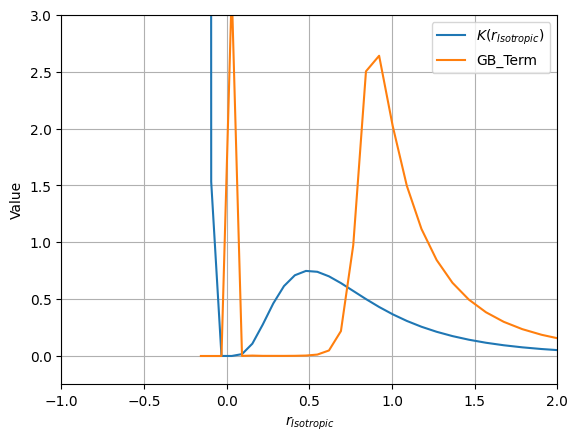

In [18]:


#plt.plot(sz_r, Kretschmann(sz_r), label='K')

plt.plot(r, Kretschmann(iso_to_sz(r)), label='$K(r_{Isotropic})$')
#plt.plot(r, line1, label = 'line1 (r_{isotropic})$')
#plt.plot(r, line2, label = 'line2 (r_{isotropic})$')
#plt.plot(r, line3, label = 'line3 (r_{isotropic})$')
#plt.plot(r, line4, label = 'line4 (r_{isotropic})$')
#plt.plot(r, eighttimesN, label = 'Nsquared',color="blue",  linestyle='--')
plt.plot(r, GB_Scaled, label = 'GB_Term')





plt.legend(loc='best')
plt.xlabel('$r_{Isotropic}$')
plt.ylabel('Value')
plt.legend(loc='best')
'''plt.xlim(-0.1,2)
plt.ylim(-10,1200)'''

plt.xlim(-1,2)
plt.ylim(-0.25,3)
plt.grid()

# Absolute difference LGB and K

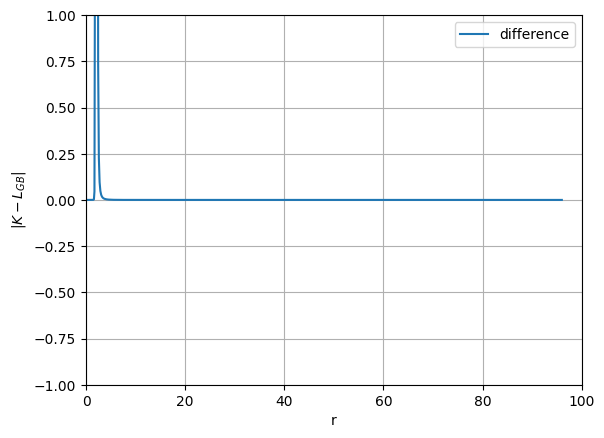

In [71]:
reldiff = np.abs(Kretschmann(iso_to_sz(r) - GB_vals_new))

plt.plot(r, reldiff , label='difference')
plt.legend(loc='best')
plt.xlabel('r')
plt.ylabel('$|K - L_{GB}|$')
plt.legend(loc='best')
plt.xlim(-0.10,100)
plt.ylim(-1,1)
plt.grid()